## Faster R-CNN test visualization
This notebook loads `face_mask_detection_faster_rcnn_final.pt` and visualizes predictions on the test split.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

PROJECT_DIR = Path.cwd().parent
MODEL_PATH = PROJECT_DIR / "models" / "face_mask_detection_faster_rcnn_final.pt"
TEST_IMAGES_DIR = PROJECT_DIR / "datasets" / "face-mask-detection-processed" / "images" / "test"
TEST_LABELS_DIR = PROJECT_DIR / "datasets" / "face-mask-detection-processed" / "labels" / "test"

CLASS_NAMES = {
    1: "With Mask",
    2: "Without Mask",
    3: "Mask Weared Incorrect",
}
COLORS = {
    1: (60, 180, 75),
    2: (230, 25, 75),
    3: (0, 130, 200),
}

def create_model(num_classes=4):
    model = fasterrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def load_checkpoint_model(model_path: Path, device: torch.device):
    checkpoint = torch.load(model_path, map_location=device)
    model = create_model(num_classes=4)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
        print(f"Loaded checkpoint epoch: {checkpoint.get('epoch', 'unknown')}")
        print(f"Checkpoint val loss: {checkpoint.get('val_loss', 'unknown')}")
    else:
        model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()
    return model

def load_yolo_gt_boxes(label_path: Path, image_width: int, image_height: int):
    boxes = []
    labels = []
    if not label_path.exists():
        return boxes, labels

    for line in label_path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        class_id = int(parts[0]) + 1
        cx, cy, bw, bh = map(float, parts[1:])
        x1 = (cx - bw / 2.0) * image_width
        y1 = (cy - bh / 2.0) * image_height
        x2 = (cx + bw / 2.0) * image_width
        y2 = (cy + bh / 2.0) * image_height
        boxes.append((x1, y1, x2, y2))
        labels.append(class_id)
    return boxes, labels

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Model path exists: {MODEL_PATH.exists()}")
print(f"Test images dir exists: {TEST_IMAGES_DIR.exists()}")
print(f"Test labels dir exists: {TEST_LABELS_DIR.exists()}")

image_paths = sorted([p for p in TEST_IMAGES_DIR.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
print(f"Number of test images: {len(image_paths)}")

model = load_checkpoint_model(MODEL_PATH, device)

Device: cpu
Model path exists: True
Test images dir exists: True
Test labels dir exists: True
Number of test images: 578
Loaded checkpoint epoch: 6
Checkpoint val loss: 0.23158823738396683


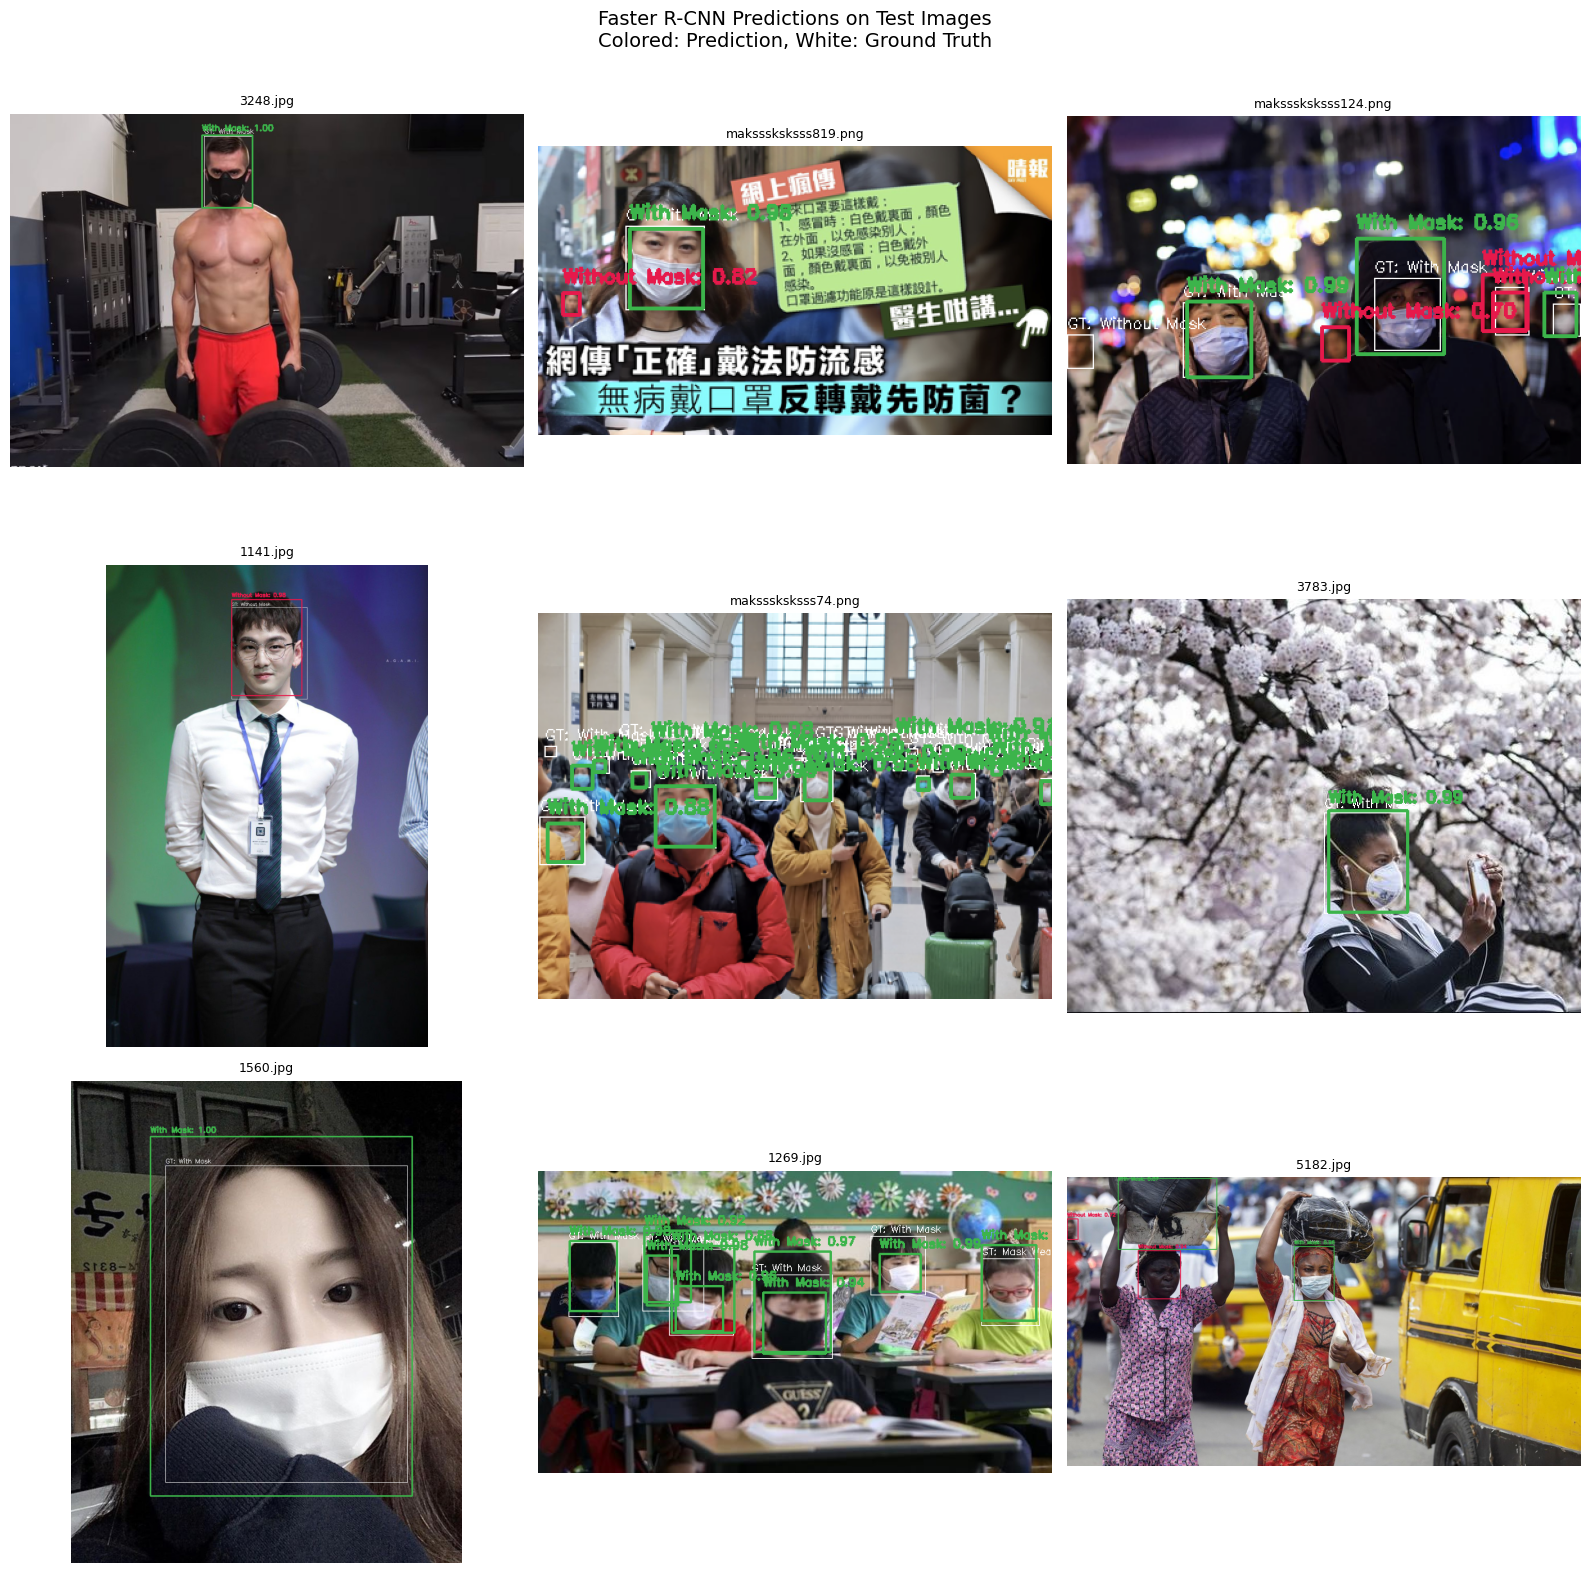

In [2]:
def predict_image(model, image_rgb, score_threshold=0.7, max_detections=15):
    image_tensor = torch.as_tensor(image_rgb, dtype=torch.float32).permute(2, 0, 1) / 255.0
    image_tensor = image_tensor.to(device)

    with torch.no_grad():
        output = model([image_tensor])[0]

    boxes = output["boxes"].detach().cpu().numpy()
    labels = output["labels"].detach().cpu().numpy()
    scores = output["scores"].detach().cpu().numpy()

    keep = scores >= score_threshold
    boxes = boxes[keep]
    labels = labels[keep]
    scores = scores[keep]

    if len(scores) > max_detections:
        order = np.argsort(-scores)[:max_detections]
        boxes = boxes[order]
        labels = labels[order]
        scores = scores[order]

    return boxes, labels, scores


def draw_predictions(image_rgb, pred_boxes, pred_labels, pred_scores, gt_boxes=None, gt_labels=None):
    drawn = image_rgb.copy()

    if gt_boxes is not None and gt_labels is not None:
        for box, label in zip(gt_boxes, gt_labels):
            x1, y1, x2, y2 = [int(v) for v in box]
            cv2.rectangle(drawn, (x1, y1), (x2, y2), (255, 255, 255), 1)
            gt_name = CLASS_NAMES.get(int(label), str(label))
            cv2.putText(drawn, f"GT: {gt_name}", (x1, max(y1 - 5, 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

    for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
        x1, y1, x2, y2 = [int(v) for v in box]
        color = COLORS.get(int(label), (255, 255, 0))
        name = CLASS_NAMES.get(int(label), str(label))
        cv2.rectangle(drawn, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            drawn,
            f"{name}: {score:.2f}",
            (x1, max(y1 - 8, 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2,
        )
    return drawn


sample_count = min(9, len(image_paths))
random_state = np.random.RandomState(42)
sample_paths = list(random_state.choice(image_paths, size=sample_count, replace=False))

fig, axes = plt.subplots(3, 3, figsize=(16, 16))
axes = axes.flatten()

for axis, image_path in zip(axes, sample_paths):
    image_bgr = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    h, w = image_rgb.shape[:2]

    pred_boxes, pred_labels, pred_scores = predict_image(
        model,
        image_rgb,
        score_threshold=0.7,
        max_detections=15,
    )
    gt_boxes, gt_labels = load_yolo_gt_boxes(TEST_LABELS_DIR / f"{image_path.stem}.txt", w, h)

    drawn = draw_predictions(image_rgb, pred_boxes, pred_labels, pred_scores, gt_boxes, gt_labels)
    axis.imshow(drawn)
    axis.set_title(image_path.name, fontsize=9)
    axis.axis("off")

for axis in axes[len(sample_paths):]:
    axis.axis("off")

plt.suptitle("Faster R-CNN Predictions on Test Images\nColored: Prediction, White: Ground Truth", fontsize=14)
plt.tight_layout()
plt.show()

In [3]:
# Quick summary on a larger subset of test images
check_count = min(100, len(image_paths))
check_paths = image_paths[:check_count]

detection_counts = []
score_means = []

for image_path in check_paths:
    image_bgr = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    pred_boxes, pred_labels, pred_scores = predict_image(model, image_rgb, score_threshold=0.5)
    detection_counts.append(len(pred_boxes))
    score_means.append(float(np.mean(pred_scores)) if len(pred_scores) > 0 else 0.0)

print(f"Evaluated {check_count} test images")
print(f"Images with >=1 detection: {sum(c > 0 for c in detection_counts)} / {check_count}")
print(f"Average detections per image: {np.mean(detection_counts):.2f}")
print(f"Average confidence (for kept detections): {np.mean([s for s in score_means if s > 0]) if any(s > 0 for s in score_means) else 0.0:.3f}")

Evaluated 100 test images
Images with >=1 detection: 100 / 100
Average detections per image: 2.39
Average confidence (for kept detections): 0.955


In [ ]:
# Per-class detection metrics (IoU-based matching)
import pandas as pd


def box_iou_xyxy(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter_area

    return inter_area / union if union > 0 else 0.0


def greedy_match(pred_boxes, pred_labels, gt_boxes, gt_labels, iou_thr=0.5):
    pairs = []
    for p_idx, p_box in enumerate(pred_boxes):
        for g_idx, g_box in enumerate(gt_boxes):
            iou = box_iou_xyxy(p_box, g_box)
            if iou >= iou_thr:
                pairs.append((iou, p_idx, g_idx))

    pairs.sort(reverse=True, key=lambda x: x[0])
    used_preds = set()
    used_gts = set()
    matches = []

    for iou, p_idx, g_idx in pairs:
        if p_idx in used_preds or g_idx in used_gts:
            continue
        used_preds.add(p_idx)
        used_gts.add(g_idx)
        matches.append((p_idx, g_idx, iou))

    unmatched_preds = [i for i in range(len(pred_boxes)) if i not in used_preds]
    unmatched_gts = [i for i in range(len(gt_boxes)) if i not in used_gts]
    return matches, unmatched_preds, unmatched_gts


def safe_div(a, b):
    return a / b if b > 0 else 0.0


score_threshold = 0.5
iou_threshold = 0.5
max_eval_images = len(image_paths)

# Label 0 is background (missed GT or unmatched prediction pairing)
y_true = []
y_pred = []

eval_paths = image_paths[:max_eval_images]
for image_path in eval_paths:
    image_bgr = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    h, w = image_rgb.shape[:2]

    pred_boxes, pred_labels, pred_scores = predict_image(
        model,
        image_rgb,
        score_threshold=score_threshold,
        max_detections=300,
    )
    gt_boxes, gt_labels = load_yolo_gt_boxes(
        TEST_LABELS_DIR / f"{image_path.stem}.txt",
        w,
        h,
    )

    gt_boxes = np.array(gt_boxes, dtype=np.float32) if len(gt_boxes) > 0 else np.zeros((0, 4), dtype=np.float32)
    gt_labels = np.array(gt_labels, dtype=np.int64) if len(gt_labels) > 0 else np.zeros((0,), dtype=np.int64)

    matches, unmatched_preds, unmatched_gts = greedy_match(
        pred_boxes,
        pred_labels,
        gt_boxes,
        gt_labels,
        iou_thr=iou_threshold,
    )

    for p_idx, g_idx, _ in matches:
        y_true.append(int(gt_labels[g_idx]))
        y_pred.append(int(pred_labels[p_idx]))

    for g_idx in unmatched_gts:
        y_true.append(int(gt_labels[g_idx]))
        y_pred.append(0)

    for p_idx in unmatched_preds:
        y_true.append(0)
        y_pred.append(int(pred_labels[p_idx]))


rows = []
for class_id, class_name in CLASS_NAMES.items():
    mask_true_pos = [(yt == class_id and yp == class_id) for yt, yp in zip(y_true, y_pred)]
    mask_fp = [(yt != class_id and yp == class_id) for yt, yp in zip(y_true, y_pred)]
    mask_fn = [(yt == class_id and yp != class_id) for yt, yp in zip(y_true, y_pred)]
    mask_tn = [(yt != class_id and yp != class_id) for yt, yp in zip(y_true, y_pred)]

    tp = int(np.sum(mask_true_pos))
    fp = int(np.sum(mask_fp))
    fn = int(np.sum(mask_fn))
    tn = int(np.sum(mask_tn))

    precision = safe_div(tp, tp + fp)
    recall = safe_div(tp, tp + fn)
    specificity = safe_div(tn, tn + fp)
    balanced_accuracy = (recall + specificity) / 2.0
    f1 = safe_div(2 * precision * recall, precision + recall)

    # One-vs-rest accuracy can be inflated for rare classes because TN dominates.
    accuracy_ovr = safe_div(tp + tn, tp + tn + fp + fn)

    rows.append(
        {
            "class_id": class_id,
            "class_name": class_name,
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1_score": round(f1, 4),
            "accuracy_ovr": round(accuracy_ovr, 4),
            "balanced_accuracy": round(balanced_accuracy, 4),
            "specificity": round(specificity, 4),
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
            "support(gt)": int(np.sum(np.array(y_true) == class_id)),
        }
    )

metrics_df = pd.DataFrame(rows)

macro_precision = metrics_df["precision"].mean()
macro_recall = metrics_df["recall"].mean()
macro_f1 = metrics_df["f1_score"].mean()
macro_balanced_acc = metrics_df["balanced_accuracy"].mean()

print(f"Evaluated images: {len(eval_paths)}")
print(f"Scoring thresholds -> conf: {score_threshold}, iou: {iou_threshold}")
print("\nMacro summary (class-balanced):")
print(f"  Macro Precision:        {macro_precision:.4f}")
print(f"  Macro Recall:           {macro_recall:.4f}")
print(f"  Macro F1-score:         {macro_f1:.4f}")
print(f"  Macro Balanced Acc.:    {macro_balanced_acc:.4f}")

print("\nNote: 'accuracy_ovr' is one-vs-rest accuracy and may be high for rare classes.")
display(metrics_df)
